In [2]:
!mamba install pandas numpy matplotlib

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 6.982799999997019 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.3    np23py313h1e705a5_0  emscripten-forge-4x
+ python-tzdata  2026.2   pyhd8ed1ab_0         conda-forge
- pip            26.1.2   pyh145f28c_0         conda-forge


      RELIANCE      INFY  HDFCBANK  TATAMOTORS
Day1       NaN       NaN       NaN         NaN
Day2  0.017857  0.013793 -0.012500    0.028846
Day3 -0.007018 -0.006803  0.018987   -0.013084
Day4  0.024735  0.020548  0.009317    0.022727
Day5 -0.006897  0.013423 -0.006154    0.027778
Day6  0.024306 -0.006623  0.015480   -0.012613

Units Purchased for each Asset:
RELIANCE       89.285714
INFY          172.413793
HDFCBANK      156.250000
TATAMOTORS    480.769231
Name: Day1, dtype: float64

Portfolio value for all 6 days:
Day1    1.000000e+06
Day2    1.011999e+06
Day3    1.009811e+06
Day4    1.029347e+06
Day5    1.036658e+06
Day6    1.041725e+06
dtype: float64


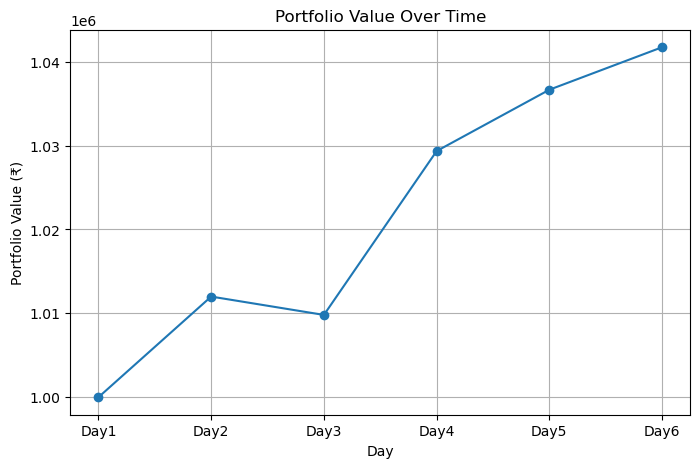

Annual Volatility: 0.12753896913611115


In [19]:
#Question 1
#(a) Creating a DataFrame and Displaying Returns Matrix
import pandas as pd
import numpy as np

prices_df = pd.DataFrame({
    "RELIANCE":[2800,2850,2830,2900,2880,2950],
    "INFY":[1450,1470,1460,1490,1510,1500],
    "HDFCBANK":[1600,1580,1610,1625,1615,1640],
    "TATAMOTORS":[520,535,528,540,555,548]
}, index=[f"Day{i}" for i in range(1,7)])

returns_df = prices_df.pct_change()
print(returns_df)

#(b ) Vectorized Calculation of Daily Portfolio Values
capital = 1_000_000
weights = np.array([0.25,0.25,0.25,0.25])
allocation = capital*weights
units = allocation/prices_df.iloc[0]
print()
print("Units Purchased for each Asset:")
print(units)
print()
print("Portfolio value for all 6 days:")
portfolio_value = prices_df.dot(units)
print(portfolio_value)

#Generating Plot of Portfolio Value over Time
import matplotlib.pyplot as plt
portfolio_value.plot(figsize=(8,5),marker='o')

plt.title("Portfolio Value Over Time")
plt.ylabel("Portfolio Value (₹)")
plt.xlabel("Day")
plt.grid(True)
plt.show()

#(c) Computation of Annualized Volatility
portfolio_returns = portfolio_value.pct_change().dropna() #Portfolio Daily Returns
daily_vol = portfolio_returns.std() #Daily Volatility
annual_vol = daily_vol*np.sqrt(252) #Annualized volatility
print("Annual Volatility:",annual_vol)


Var95: 0.02142302518716086
Var99: 0.028600107969996843
VaR95:On 95% of days losses should not exceed 2.142302518716086 %
VaR99:On 99% of days losses should not exceed 2.8600107969996844 %

CVar95: 0.02676743592056375
CVar99: 0.03216228302674122
VaR only tells where the tail begins whereas CVaR tells average loss once we are inside the tail

Max_dd: 0.18828271612926054


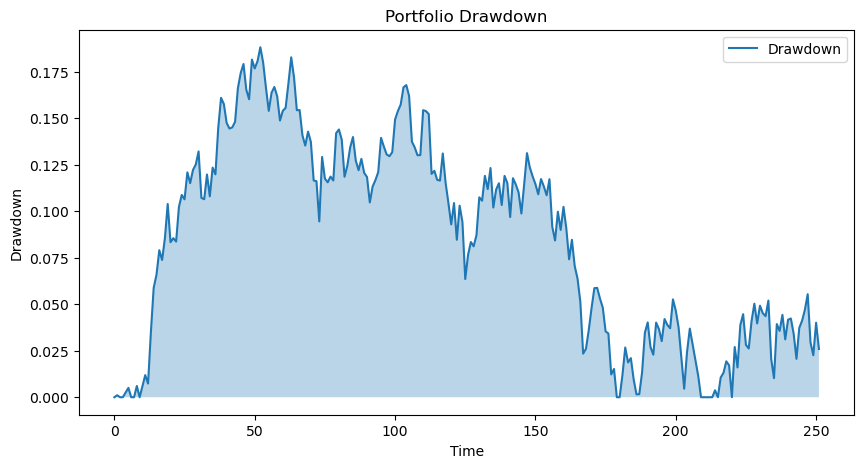

In [22]:
#Question 2
#Generate data
np.random.seed(42)
returns = np.random.normal(loc=0.001,scale=0.015,size=252)

#(a) Computation of Historical VaR
VaR95 = -np.percentile(returns,5) #95% VaR
VaR99 = -np.percentile(returns,1) #99% VaR
print("Var95:",VaR95)
print("Var99:",VaR99)
#Interpretation
print("VaR95:On 95% of days losses should not exceed",VaR95*100,"%")
print("VaR99:On 99% of days losses should not exceed",VaR99*100,"%")
print()

#(b) Computation of Conditional VaR
threshold95 = np.percentile(returns,5)
CVaR95 = -returns[returns<=threshold95].mean()
threshold99 = np.percentile(returns,1)
CVaR99 = -returns[returns<=threshold99].mean()
print("CVar95:",CVaR95)
print("CVar99:",CVaR99)
print("VaR only tells where the tail begins whereas CVaR tells average loss once we are inside the tail")
print()

#(c) Computation of Maximum Drawdown
portfolio_values = 1000000*np.cumprod(1+returns) #Portfolio Simulation
running_peak = np.maximum.accumulate(portfolio_values)
drawdown = (running_peak- portfolio_values)/running_peak
max_dd = drawdown.max()
print("Max_dd:",max_dd)
#Generating Plot of Maximum Drawdown over Time
plt.figure(figsize=(10,5))
plt.plot(drawdown,label='Drawdown')
plt.fill_between(range(len(drawdown)),drawdown,alpha=0.3)
plt.title("Portfolio Drawdown")
plt.ylabel("Drawdown")
plt.xlabel("Time")
plt.legend()
plt.show()


In [25]:
#Question 3
#(a) Computation of Sharpe Ratio
mean_daily = returns.mean()
annual_return = mean_daily*252
annual_vol = returns.std()*np.sqrt(252)
sharpe = (annual_return-0.06)/annual_vol
print("Sharpe Ratio:",sharpe)
print()

#(b) Computation of Sortino Ratio
downside = returns[returns<0] #Only negative returns
downside_std = downside.std()*np.sqrt(252) #Downside deviation
sortino = (annual_return-0.06)/downside_std
print("Sortino Ratio:",sortino)
print("Sharpe penalises both upside volatility and downside volatility while Sortino penalises only downside volatility showing strategies with large positive jumps obtain better Sortino ratios")
print()

#(c) Comparison Table
metrics = pd.DataFrame({
    "Metric":["Sharpe","Sortino"],
    "Value":[sharpe,sortino]
})
print(metrics)
print("Sortino is preferable because investors dislike downside risk rather than upside surprises")

Sharpe Ratio: 0.7734000704208027

Sortino Ratio: 1.415402199370348
Sharpe penalises both upside volatility and downside volatility while Sortino penalises only downside volatility showing strategies with large positive jumps obtain better Sortino ratios

    Metric     Value
0   Sharpe  0.773400
1  Sortino  1.415402
Sortino is preferable because investors dislike downside risk rather than upside surprises


Number of Buy Signals: 3
Number of Sell Signals: 2

Strategy Cumulative Return:
31.0866%

Buy-and-Hold Cumulative Return:
4.6118%

Final Strategy Value:
₹131,086.58

Final Buy-and-Hold Value:
₹104,611.84


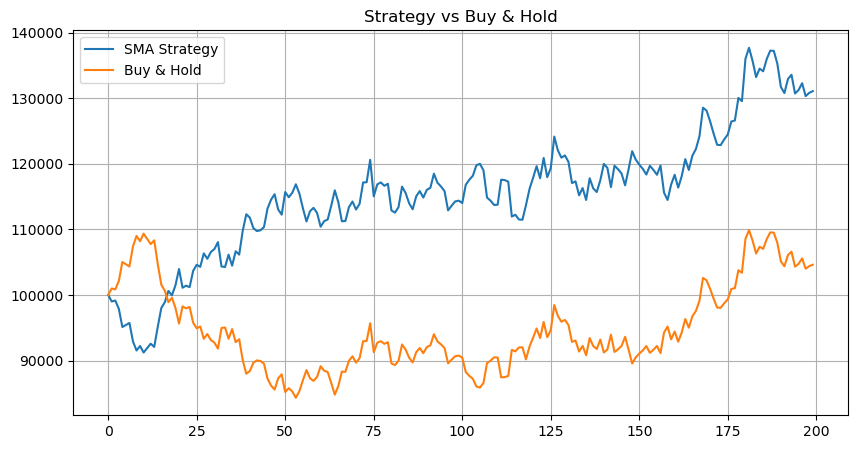

Win Rate: 0.5376884422110553
Profit Factor: 1.254142818502897
A Profit Factor > 1 does not guarantee a good strategy because:
It ignores drawdowns.
It ignores risk.
It may result from very few trades.
It may be overfit to historical data.

A complete evaluation should also include:
Sharpe Ratio
Sortino Ratio
Maximum Drawdown
Out-of-sample performance


In [30]:
#Question 4
#Generating Price Series
np.random.seed(42)
eps = np.random.normal(0.001,0.018,200)
prices = [1000]
for e in eps:
    prices.append(prices[-1]*(1+e))
prices = pd.Series(prices[:200])

#(a) Implementation of SMA Crossover Strategy

#Calculating Moving Averages
sma10 = prices.rolling(10).mean()
sma30 = prices.rolling(30).mean()

# Generating Signals
signal = np.where(sma10>sma30,1,-1)
signal = pd.Series(signal)
crossovers = signal.diff() #Detect Crissovers
buy_signals = np.sum(crossovers == 2)
sell_signals = np.sum(crossovers == -2)

print("Number of Buy Signals:", buy_signals)
print("Number of Sell Signals:", sell_signals)

#(b)
# Computation of Strategy Cumulative Return
asset_returns = prices.pct_change().fillna(0) #Daily Returns

#Strategy Returns
strategy_returns = (signal.shift(1)* asset_returns)
strategy_returns.fillna(0,inplace=True)


# Computation of Buy and Hold Cumulative Return
capital = 100000
strategy_value = capital*np.cumprod(1+strategy_returns)
buyhold_value = capital*np.cumprod(1+asset_returns)
strategy_cum_return = (strategy_value.iloc[-1]/capital)-1
buyhold_cum_return = (buyhold_value.iloc[-1]/capital)-1
print("\nStrategy Cumulative Return:")
print(f"{strategy_cum_return:.4%}")
print("\nBuy-and-Hold Cumulative Return:")
print(f"{buyhold_cum_return:.4%}")

print("\nFinal Strategy Value:")
print(f"₹{strategy_value.iloc[-1]:,.2f}")

print("\nFinal Buy-and-Hold Value:")
print(f"₹{buyhold_value.iloc[-1]:,.2f}")

# Plot
plt.figure(figsize=(10,5))
plt.plot(strategy_value,label="SMA Strategy")
plt.plot(buyhold_value,label="Buy & Hold")
plt.title("Strategy vs Buy & Hold")
plt.legend()
plt.grid(True)
plt.show()

#(c) 
# Computation of Win Rate
wins = strategy_returns[strategy_returns>0]
losses = strategy_returns[strategy_returns<0]
win_rate = (len(wins)/(len(wins)+len(losses)))
print("Win Rate:", win_rate)

#Computation of Profit Factor
profit_factor = (wins.sum()/abs(losses.sum()))
print("Profit Factor:", profit_factor)

#Explanation for why Profit Factor>1 is not a good strategy
print("A Profit Factor > 1 does not guarantee a good strategy because:")
print("It ignores drawdowns.")
print("It ignores risk.")
print("It may result from very few trades.")
print("It may be overfit to historical data.")
print()
print("A complete evaluation should also include:")
print("Sharpe Ratio")
print("Sortino Ratio")
print("Maximum Drawdown")
print("Out-of-sample performance")

        Price
0  500.000000
1  504.970427
2  504.218649
3  510.601247
4  525.109745
        Price  Return_1d       SMA_5      SMA_20  Volatility_10  Momentum_5
0  490.180058  -0.015344  498.710610  520.018795       0.014872  -33.381792
1  478.209142  -0.024421  492.786520  518.929252       0.013596  -29.620449
2  491.303310   0.027382  490.407665  518.245896       0.018731  -11.894277
3  489.797970  -0.003064  489.461857  517.524862       0.018842   -4.729040
4  490.883121   0.002216  488.074720  516.538956       0.018595   -6.935684
        Price  Return_1d       SMA_5      SMA_20  Volatility_10  Momentum_5  \
0  490.180058  -0.015344  498.710610  520.018795       0.014872  -33.381792   
1  478.209142  -0.024421  492.786520  518.929252       0.013596  -29.620449   
2  491.303310   0.027382  490.407665  518.245896       0.018731  -11.894277   
3  489.797970  -0.003064  489.461857  517.524862       0.018842   -4.729040   
4  490.883121   0.002216  488.074720  516.538956       0.018595  

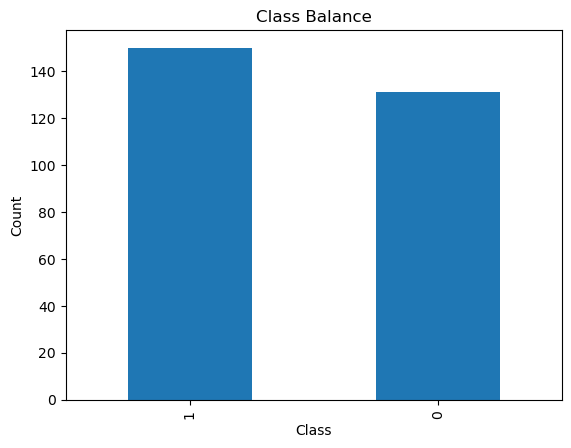

Return_1d        0.0
SMA_5            0.0
SMA_20           0.0
Volatility_10    0.0
Momentum_5       0.0
dtype: float64
Return_1d        1.0
SMA_5            1.0
SMA_20           1.0
Volatility_10    1.0
Momentum_5       1.0
dtype: float64
Scaling is important because KNN uses Euclidean distance and ensures all features contribute equally as without scaling SMA dominates the distance calculation


In [32]:
# Question 5
#Generating Price Series
np.random.seed(42)
n_days = 300
eps = np.random.normal(
    loc=0.001,
    scale=0.018,
    size=n_days
)
prices = [500]
for e in eps:
    prices.append(
        prices[-1]*(1+e)
    )
prices = prices[:300]
df = pd.DataFrame({
    "Price": prices
})
print(df.head())

#(a) Engineering Features
df["Return_1d"] = df["Price"].pct_change() #1-day return
df["SMA_5"] = (df["Price"].rolling(5).mean()) #SMA 5(5 day simple moving average)
df["SMA_20"] = (df["Price"].rolling(20).mean()) #SMA 20(20 day simple moving average)
df["Volatility_10"] = (df["Return_1d"].rolling(10).std()) #Volatility 10(Rolling 10-day standarddeviation of returns)
df["Momentum_5"] = (df["Price"]-df["Price"].shift(5)) #5_day price momentum
df = df.dropna() #Removing NaNs
df = df.reset_index(drop=True) #Resetting index
print(df.head())

#(b) Creating Binary Target Variable
future_return = (df["Return_1d"].shift(-1))
df["Target"] = (future_return > 0).astype(int)
df = df.dropna()
print(df.head())

print("Class balance refers to the relative frequency or distribution of target labels within a dataset.")
print("A dataset is considered perfectly balanced when each target class contains an approximately equal number of examples.")
class_counts = (df["Target"].value_counts()) #Class Balance
print(class_counts)
balance = (class_counts/len(df))*100 #Percentage Balance
print(balance)

# Bar Chart
class_counts.plot(kind="bar")
plt.title("Class Balance")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

#(c) Normalising features using Min-Max scaling
#Selecting Features
features = ["Return_1d","SMA_5","SMA_20","Volatility_10","Momentum_5"]
X = df[features]
X_scaled = (X - X.min()) / (X.max() - X.min()) #Scaling
print(X_scaled.min())
print(X_scaled.max())
print("Scaling is important because KNN uses Euclidean distance and ensures all features contribute equally as without scaling SMA dominates the distance calculation")

Accuracies:
3 0.5263157894736842
5 0.5263157894736842
7 0.49122807017543857
11 0.49122807017543857
15 0.5964912280701754


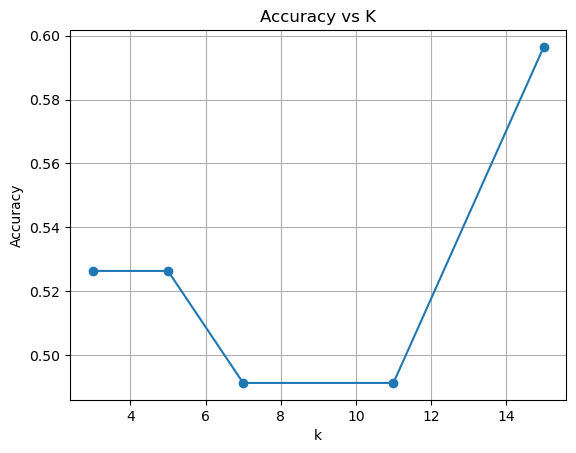

Best k: 15
          Pred 1  Pred 0
Actual 1      16      11
Actual 0      12      18
If false positives are costly trades, Precision is more important as False Positive means model saying buy when the market falls and high precision just reduces bad trades because of that


In [35]:
#Question 6

#(a)
#Euclidean Distance Function
def euclidean_distance(x1,x2):
    return np.sqrt(np.sum((x1-x2)**2))
    
#KNN Prediction Function   
def knn_predict(X_train,y_train,X_test,k):
    predictions = []
    for test_point in X_test:
        distances = np.sqrt(np.sum((X_train-test_point)**2,axis=1)) #(i)
        nearest_idx = (np.argsort(distances)[:k]) #(ii)
        nearest_labels = (y_train[nearest_idx]) 
        prediction = (np.bincount(nearest_labels).argmax()) 
        predictions.append(prediction)
    return np.array(predictions) #(iii)

#(b)
#Train Test Split 80/20
X = X_scaled.values
y = df["Target"].values
split = int(0.8*len(X))
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

#Test multiple k values
k_values = [3,5,7,11,15]
accuracies = []
print("Accuracies:")
for k in k_values:
    pred = knn_predict(X_train,y_train,X_test,k)
    accuracy = np.mean(pred == y_test)
    accuracies.append(accuracy)
    print(k,accuracy)

#Accuracy VS k Plot
plt.plot(k_values,accuracies,marker='o')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.grid(True)
plt.show()
best_k = k_values[np.argmax(accuracies)]
print("Best k:",best_k)

#(c)
#Confusion Matrix
pred = knn_predict(X_train,y_train,X_test,best_k)
TP = np.sum((pred==1)&(y_test==1))
TN = np.sum((pred==0)&(y_test==0))
FP = np.sum((pred==1)&(y_test==0))
FN = np.sum((pred==0)&(y_test==1))
cm = pd.DataFrame([[TP,FP],[FN,TN]],index=["Actual 1","Actual 0"],columns=["Pred 1","Pred 0"])
print(cm)

precision = (TP/(TP+FP))
recall = (TP/(TP+FN))
print("If false positives are costly trades, Precision is more important as False Positive means model saying buy when the market falls and high precision just reduces bad trades because of that")


Beta: [ 0.01239002 -0.01016527  0.01266044 -0.01128772 -0.00692145 -0.00847475]
If the coefficient is positive, feature increases return prediction while if the coefficient is negative, feature decreases return prediction
Higher momentum predicts higher future returns while higher volatility predicts lower future returns
   Actual Return  Predicted Return
0      -0.024421          0.004265
1       0.027382          0.005016
2      -0.003064         -0.002519
3       0.002216         -0.000599
4      -0.024645         -0.000799
5      -0.008799          0.002083
6       0.002997          0.001161
7      -0.019718          0.000792
8       0.007763          0.002930
9      -0.009811          0.000524
MSE: 0.00030990184955785463
R^2: 0.01945927542605197


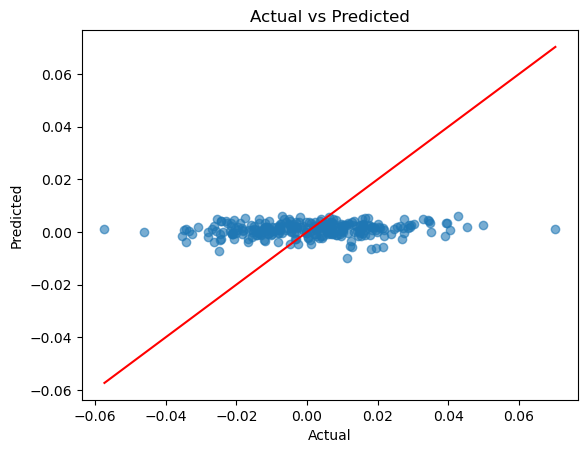

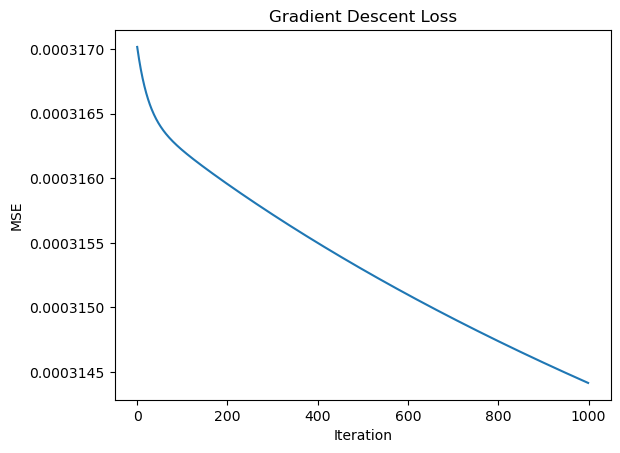

Normal Equation:
[ 0.01239002 -0.01016527  0.01266044 -0.01128772 -0.00692145 -0.00847475]
Gradient Descent:
[ 2.48787698e-03 -1.23800196e-03 -9.28334557e-05 -1.82470307e-04
 -1.53108590e-03 -5.75710514e-04]


In [47]:
#Question 7
#(a)
#Continuous Target
y_reg = (df["Return_1d"].shift(-1))
df_reg = df.copy()
df_reg["TargetReturn"] = y_reg
df_reg = df_reg.dropna()
#X
X = X_scaled.iloc[:len(df_reg)].values
y = df_reg["TargetReturn"].values
#Adding Bias Column of ones
X_bias = np.c_[np.ones(len(X)), X]
#Printing learned coefficients
beta = beta = np.linalg.pinv(X_bias) @ y
print("Beta:",beta)
print("If the coefficient is positive, feature increases return prediction while if the coefficient is negative, feature decreases return prediction")
print("Higher momentum predicts higher future returns while higher volatility predicts lower future returns")

#(b)
#Predict Returns
y_pred = (X_bias @ beta)
predictions_df = pd.DataFrame({"Actual Return": y,"Predicted Return": y_pred})
print(predictions_df.head(10))

mse_reg = np.mean((y-y_pred)**2)
mse = np.mean((y-y_pred)**2) #Computing MSE
print("MSE:",mse)

r2 = (1 -np.sum((y-y_pred)**2)/np.sum((y-y.mean())**2)) #Computing R^2
print("R^2:",r2)

#Actual VS Predicted Plot
plt.scatter(y,y_pred,alpha=0.6)
plt.plot([y.min(),y.max()],[y.min(),y.max()],'r')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

#(c)
#Gradient Descent
beta_gd = np.zeros(X_bias.shape[1])
eta = 0.01
losses = []
n = len(X_bias)
for i in range(1000):
    pred = (X_bias@beta_gd)
    error = (pred-y)
    gradient = (X_bias.T@error)/n
    beta_gd = (beta_gd-eta*gradient)
    mse = np.mean(error**2)
    losses.append(mse)
    
#Loss Curve
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Gradient Descent Loss")
plt.show()

#Convergence Check
print("Normal Equation:")
print(beta)
print("Gradient Descent:")
print(beta_gd)


Asset Features:
[[ 1.00000000e+00  2.43055556e-02  2.88200000e+03  2.86833333e+03
   1.62543319e-02  1.50000000e+02]
 [ 1.00000000e+00 -6.62251656e-03  1.48600000e+03  1.48000000e+03
   1.27175691e-02  5.00000000e+01]
 [ 1.00000000e+00  1.54798762e-02  1.61400000e+03  1.61166667e+03
   1.37364746e-02  4.00000000e+01]
 [ 1.00000000e+00 -1.26126126e-02  5.41200000e+02  5.37666667e+02
   2.16491675e-02  2.80000000e+01]]
Expected Return Vector:
[2.85125984 1.69621866 1.91505414 0.55787423]
Portfolio Weights:
[0.40613883 0.24161259 0.27278392 0.07946466]
Sum of Weights: 0.9999999999999999


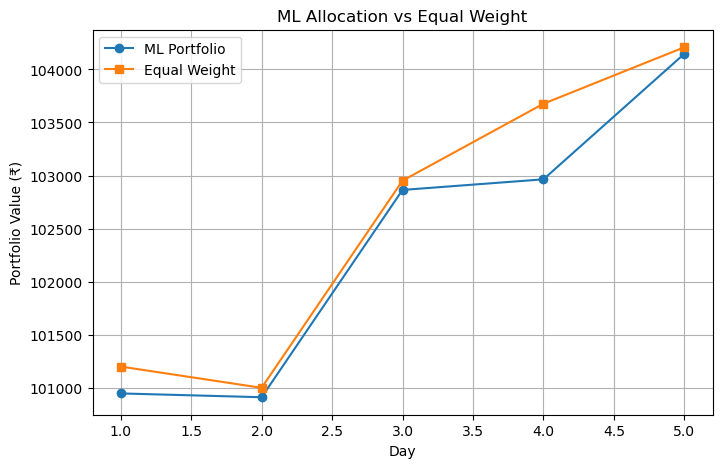

Final ML Portfolio Value:
104147.55336046593
Final Equal Weight Value:
104209.2847790064
ML-driven Portfolio does not outperform
Limitation of this approach is that portfolio weights depend entirely on the regression model's forecasts. If the predicted returns are inaccurate, the portfolio may allocate more capital to underperforming assets, leading to worse performance than a simple equal-weight strategy.


In [42]:
#Question 8
#(a) Arrange Predicted Returns in a Numpy Array
# Prices from Problem 1
prices_df = pd.DataFrame({"RELIANCE":[2800,2850,2830,2900,2880,2950],"INFY":[1450,1470,1460,1490,1510,1500],"HDFCBANK":[1600,1580,1610,1625,1615,1640],"TATAMOTORS":[520,535,528,540,555,548]})
asset_features = []
for asset in prices_df.columns:
    p = prices_df[asset]
    ret = p.pct_change()
    latest_return = ret.iloc[-1]
    sma5 = p.rolling(5).mean().iloc[-1]
    sma20_proxy = p.mean()
    vol_proxy = ret.std()
    momentum5 = p.iloc[-1] - p.iloc[0]
    asset_features.append([1,latest_return,sma5,sma20_proxy,vol_proxy,momentum5])
asset_features = np.array(asset_features)
print("Asset Features:")
print(asset_features)
expected_returns = asset_features @ beta
print("Expected Return Vector:")
print(expected_returns)

#(b) Assigning Portfolio weights proportional to Predicted Returns
positive_returns = np.maximum(expected_returns,0)
weights = positive_returns / positive_returns.sum()
print("Portfolio Weights:")
print(weights)
print("Sum of Weights:",weights.sum())

#(c) Backtesting the ML Portfolio
returns_df = prices_df.pct_change().dropna()
ml_returns = returns_df @ weights
equal_weights = np.array([0.25,0.25,0.25,0.25])
equal_returns = returns_df @ equal_weights
capital = 100000
ml_value = capital*np.cumprod(1+ml_returns)
equal_value = capital*np.cumprod(1+equal_returns)

#Plot comparison
plt.figure(figsize=(8,5))
plt.plot(ml_value,marker='o',label='ML Portfolio')
plt.plot(equal_value,marker='s',label='Equal Weight')
plt.xlabel("Day")
plt.ylabel("Portfolio Value (₹)")
plt.title("ML Allocation vs Equal Weight")
plt.legend()
plt.grid(True)
plt.show()

#Comparing Final Wealth
print("Final ML Portfolio Value:")
print(ml_value.iloc[-1])

print("Final Equal Weight Value:")
print(equal_value.iloc[-1])
if (ml_value.iloc[-1]<equal_value.iloc[-1]):
    print("ML-driven Portfolio does not outperform")
else:
    print("ML-driven Portfolio outperforms")
print("Limitation of this approach is that portfolio weights depend entirely on the regression model's forecasts. If the predicted returns are inaccurate, the portfolio may allocate more capital to underperforming assets, leading to worse performance than a simple equal-weight strategy.")


In [50]:
#Question 9
#(a) k-Fold Cross Validation
k_values = [3,7,11]
results = []
X_cv = X_scaled.values
y_cv = df["Target"].values.astype(int)
n = len(X_cv)
fold_size = n // 5
for k in k_values:
    fold_accuracies = []
    for fold in range(5):
        start = fold * fold_size
        end = start + fold_size
        X_test = X_cv[start:end]
        y_test = y_cv[start:end]
        X_train = np.concatenate([X_cv[:start], X_cv[end:]],axis=0)
        y_train = np.concatenate([y_cv[:start], y_cv[end:]],axis=0)
        pred = knn_predict(X_train,y_train,X_test,k)
        acc = np.mean(pred == y_test)
        fold_accuracies.append(acc)
    #Calculate Average Accuracy        
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    results.append([k,mean_acc,std_acc])
    print(f"\nK = {k}")
    print("Fold Accuracies:", fold_accuracies)
    print("Mean Accuracy:", mean_acc)
    print("Std Accuracy:", std_acc)
#Results Table
cv_results = pd.DataFrame(results,columns=["K","Mean Accuracy","Std Accuracy"])
print(cv_results)
best_row = cv_results.loc[cv_results["Mean Accuracy"].idxmax()]
best_k = int(best_row["K"])
print("Best K =", best_k)

#(b) Model Comparison Table
comparison = pd.DataFrame({
    "Model":["KNN Classifier","Linear Regression"],
    "Accuracy/R²":[round(best_row["Mean Accuracy"],4),round(r2,4)],
    "MSE/N.A.":["N.A.",round(mse_reg,6)],
    "Best Param":[f"k={best_k}","N.A."]})
print(comparison)
#(c)
print()
print("Based on the results obtained in part (b), I would deploy the KNN classifier if the primary objective is to predict the direction of future price movement (up/down), since its performance can be directly interpreted in terms of classification accuracy. If the objective is to estimate the magnitude of future returns, then Linear Regression would be more appropriate because it produces continuous return forecasts.")
print("For this assignment, I would prefer the KNN classifier because its cross-validation accuracy was relatively stable across folds and it requires fewer assumptions about the relationship between features and target variables.")
print("However, there are several risks associated with deploying machine learning models in a live trading environment.")
print("The first risk is overfitting. A model may learn noise or patterns that exist only in historical data. Such a model can perform well during training and testing but fail when exposed to new market conditions.")
print("The second risk is look-ahead bias. This occurs when future information accidentally leaks into the training process. Such leakage can produce unrealistically high performance metrics that cannot be achieved in real trading.")
print("Another important risk is market regime change. Financial markets evolve over time, and relationships learned from historical data may not remain valid in the future.")
print("Therefore, any machine learning model should be regularly retrained, validated on out-of-sample data, and monitored continuously before being used in a real portfolio.")



K = 3
Fold Accuracies: [np.float64(0.35714285714285715), np.float64(0.48214285714285715), np.float64(0.375), np.float64(0.5714285714285714), np.float64(0.5357142857142857)]
Mean Accuracy: 0.4642857142857143
Std Accuracy: 0.08526668847366657

K = 7
Fold Accuracies: [np.float64(0.39285714285714285), np.float64(0.5), np.float64(0.4107142857142857), np.float64(0.5357142857142857), np.float64(0.48214285714285715)]
Mean Accuracy: 0.46428571428571425
Std Accuracy: 0.054163396028939645

K = 11
Fold Accuracies: [np.float64(0.39285714285714285), np.float64(0.5535714285714286), np.float64(0.5), np.float64(0.6428571428571429), np.float64(0.4642857142857143)]
Mean Accuracy: 0.5107142857142858
Std Accuracy: 0.08421304373251141
    K  Mean Accuracy  Std Accuracy
0   3       0.464286      0.085267
1   7       0.464286      0.054163
2  11       0.510714      0.084213
Best K = 11
               Model  Accuracy/R² MSE/N.A. Best Param
0     KNN Classifier       0.5107     N.A.       k=11
1  Linear Regres

In [54]:
#Question 10
#(a) Diversification
print("(a) The second term depends on the correlation coefficient ρij between assets.")
print("When assets have low or negative correlations, the covariance term becomes smaller, reducing overall portfolio variance.")
print("If ρij=−1, losses in one asset can be completely offset by gains in another, providing the maximum diversification benefit.")
print("Therefore, combining assets with low correlations reduces total risk without necessarily reducing expected returns.")
print("This is why diversification is often called the only free lunch in finance.")
print()

#(b) Technicalvs Fundamental Analysis in ML
print("(b) One useful fundamental feature that could be added to the KNN model is the Price-to-Earnings (P/E) ratio.")
print("The P/E ratio measures how much investors are willing to pay for each unit of company earnings and can provide information about valuation.")
print("This data can be obtained from financial websites such as Yahoo Finance, Google Finance, company annual reports, or financial APIs.")
print("After collecting the P/E ratio for each stock, it can be added as an additional column in the feature matrix alongside technical indicators such as returns, momentum, and moving averages.")
print("The feature should be scaled before applying KNN so that it has a comparable influence on distance calculations.")
print()


#(c) The Curse of Dimensionality
print("(c) As more features are added to a KNN model, the distance between data points becomes less meaningful because points tend to become similarly far apart in high-dimensional space.")
print("As a result, the distinction between “nearest” and “farthest” neighbours decreases, making classification less reliable.")
print("In financial datasets, many features may also contain noise or redundant information, which can further degrade prediction accuracy.")
print("This phenomenon is known as the curse of dimensionality.")
print("One common mitigation technique is Principal Component Analysis (PCA), which reduces the number of dimensions while retaining most of the important information contained in the data.")
print()


#(d) Overfitting in Backtesting
print("(d) A large gap between a backtested Sharpe Ratio of 3.5 and a live-trading Sharpe Ratio of 0.4 can arise due to several factors.")
print("First, look-ahead bias may occur if future information accidentally leaks into the model; this can be detected using strict walk-forward or time-series validation.")
print("Second, survivorship bias can occur when only stocks that survived until today are included in historical testing; this can be detected by using survivorship-bias-free datasets.")
print("Third, data snooping (overfitting) may occur when many strategies are tested and only the best-performing one is reported; this can be detected through out-of-sample testing and cross-validation.")
print("These validation methods help ensure that backtest results are realistic and likely to generalize to future market conditions.")
print()

#(e) Linear Regression Assumptions
print("(e) Linear Regression assumes that residuals are independently and identically distributed (i.i.d.), but financial return data often violates this assumption.")
print("Autocorrelation (Serial Correlation):In financial time series, returns or residuals may be correlated with their past values rather than being independent. This means that information from previous periods influences future observations. As a result, the model may underestimate prediction errors and produce overly confident forecasts, leading to unreliable statistical significance tests.")
print("Heteroscedasticity (Time-Varying Volatility):Financial markets often experience periods of high and low volatility, meaning the variance of residuals is not constant over time. For example, market crashes typically produce much larger fluctuations than normal trading periods. This violates the identical distribution assumption and can cause the model to underestimate risk during volatile periods, reducing the accuracy of return predictions and confidence intervals.")
print("Therefore, autocorrelation and heteroscedasticity are two common violations of the i.i.d. assumption in financial data, and both can lead to misleading model estimates and prediction uncertainty.")

(a) The second term depends on the correlation coefficient ρij between assets.
When assets have low or negative correlations, the covariance term becomes smaller, reducing overall portfolio variance.
If ρij=−1, losses in one asset can be completely offset by gains in another, providing the maximum diversification benefit.
Therefore, combining assets with low correlations reduces total risk without necessarily reducing expected returns.
This is why diversification is often called the only free lunch in finance.

(b) One useful fundamental feature that could be added to the KNN model is the Price-to-Earnings (P/E) ratio.
The P/E ratio measures how much investors are willing to pay for each unit of company earnings and can provide information about valuation.
This data can be obtained from financial websites such as Yahoo Finance, Google Finance, company annual reports, or financial APIs.
After collecting the P/E ratio for each stock, it can be added as an additional column in the feature